<a href="https://colab.research.google.com/github/jrodriguezrosales/FOR606-GEOESTADISTICA/blob/main/Tarea1_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="width:100%; padding:40px; background-color:#f8fbf8; border: 2px solid #1b4332; border-radius:10px; text-align:center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">

  <h1 style="color:#1b4332; margin-bottom:5px; font-size:28px; font-weight:bold;">COLEGIO DE POSTGRADUADOS</h1>
  <h2 style="color:#1b4332; margin-top:0; font-size:20px; font-weight:normal;">CAMPUS MONTECILLO</h2>
  <h3 style="color:#333; margin-top:15px; font-size:18px; text-transform:uppercase; letter-spacing:1.5px;">Posgrado en Ciencias Forestales</h3>

  <hr style="border: 0; height: 1px; background: #1b4332; width: 50%; margin: 25px auto;">

  <div style="margin: 30px 0;">
    <h3 style="color:#555; font-size:16px; margin-bottom:10px;">CURSO:</h3>
    <p style="color:#000; font-size:18px; font-weight:bold;">FOR 606: Geoestadística aplicada en el estudio de los recursos forestales</p>
  </div>

  <div style="margin: 25px 0; background-color:#ffffff; padding:20px; border-radius:8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); border-left: 5px solid #1b4332;">
    <h2 style="color:#1b4332; font-size:22px; line-height:1.4; margin:0;">
      <b>REPORTE PRÁCTICA 1:</b><br>
      Análisis Geoestadístico de la Humedad Superficial del Suelo en la Sierra de Huehuetla, Puebla
    </h2>
  </div>

  <div style="margin-top:40px; display: flex; justify-content: space-around; text-align: left;">
    <div style="width:45%;">
      <p style="font-size:14px; color:#666; margin-bottom:2px; text-transform:uppercase;">Titular del curso:</p>
      <p style="font-size:16px; color:#000; font-weight:500;">Dra. Martha Elva Ramírez Guzmán</p>
    </div>
    <div style="width:45%; text-align: right;">
      <p style="font-size:14px; color:#666; margin-bottom:2px; text-transform:uppercase;">Presenta:</p>
      <p style="font-size:16px; color:#000; font-weight:500;">José Rodríguez Rosales</p>
    </div>
  </div>

  <div style="margin-top:50px; font-style:italic; color:#777; font-size:14px;">
    Montecillo, Texcoco, Estado de México, 2026
  </div>

</div>

## Tabla de Contenido
| # | Actividad |
|---|---|
| 0 | Instalación de paquetes |
| 1 | Carga de datos |
| 2 | Estadísticas descriptivas |
| 3 | Diagrama de tallos y hojas |
| 4 | Cuatro gráficas en una hoja |
| 5 | Grupos de alturas (estratificación) |
| 6 | QQ-Plot (normalidad) |
| 7 | Gráfica de dispersión espacial |
| 8 | Superficie de interpolación |
| 9 | Visualización 3D de la superficie |

---
## ⚙️ Actividad 0 — Instalación y carga de paquetes

> **Nota:** En Google Colab con kernel R, algunos paquetes ya están disponibles. Esta celda instala los que faltan. Puede tardar unos minutos la primera vez.

In [ ]:
install.packages(c("car", "geoR", "gstat", "lattice", "akima", "RcmdrMisc", "modeest", "psych"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’




In [ ]:
# Cargar paquetes
library(car)      # Análisis estadístico, qqPlot
library(geoR)     # Análisis de datos geoestadísticos
library(gstat)    # Modelamiento geoestadístico
library(lattice)  # Gráficos lattice
library(akima)    # Interpolación de datos irregularmente espaciados
library(RcmdrMisc)
library(modeest)
library(psych)    # Para asimetría (skew) y curtosis (kurtosi)

cat("✅ Paquetes cargados correctamente.\n")

Registered S3 method overwritten by 'psych':
  method         from  
  plot.residuals rmutil


Attaching package: ‘psych’


The following object is masked from ‘package:RcmdrMisc’:

    reliability


The following object is masked from ‘package:car’:

    logit




✅ Paquetes cargados correctamente.


---
## 📂 Carga del archivo de datos

Sube el archivo `aquifer.txt` (o `aquifer.csv`) usando el panel de archivos de Colab,
o ejecuta la celda siguiente para cargarlo directamente desde tu equipo.

In [ ]:
# OPCIÓN A: subir archivo manualmente desde tu computadora

# Si tienes el archivo .csv:
aquifer <- read.csv("/content/Humedad_Huehuetla_UTM.csv", header = TRUE, dec = ".")

cat("✅ Datos cargados.\n")
cat("Dimensiones:", nrow(aquifer), "filas x", ncol(aquifer), "columnas\n")

✅ Datos cargados.
Dimensiones: 3950 filas x 3 columnas


---
## 📋 Actividad 1 — Exploración inicial de los datos

In [ ]:
# Inspección de la estructura y primeras filas
str(aquifer)
names(aquifer)
head(aquifer, 6)

'data.frame':	3950 obs. of  3 variables:
 $ easting : chr  "640049.9999999849" "640049.9999999858" "640149.9999999849" "640249.9999999857" ...
 $ northing: chr  "2220049.999999992" "2220149.999999992" "2220149.9999999916" "2220149.999999992" ...
 $ head    : chr  "-9.96206294054678" "-11.18854586481385" "-11.800014863744694" "-5.67287929041208" ...


[1] "easting"  "northing" "head"

,easting,northing,head
,<chr>,<chr>,<chr>
1,640049.9999999849,2220049.999999992,-9.96206294054678
2,640049.9999999858,2220149.999999992,-11.18854586481385
3,640149.9999999849,2220149.9999999916,-11.800014863744694
4,640249.9999999857,2220149.999999992,-5.67287929041208
5,640349.999999986,2220149.999999992,-5.755550880371851
6,640049.9999999856,2220249.9999999925,-11.700922406742533


In [ ]:
# 1. Convertir las columnas de texto a formato numérico
aquifer$easting <- as.numeric(aquifer$easting)
aquifer$northing <- as.numeric(aquifer$northing)
aquifer$head <- as.numeric(aquifer$head)

# 2. Verificar que la estructura ahora diga 'num' (numérico) en lugar de 'chr'
str(aquifer)

# 3. Volver a calcular la media (agregamos na.rm = TRUE por si hay algún dato vacío)
cat("Media de head:", mean(aquifer$head, na.rm = TRUE), "\n")

'data.frame':	3950 obs. of  3 variables:
 $ easting : num  640050 640050 640150 640250 640350 ...
 $ northing: num  2220050 2220150 2220150 2220150 2220150 ...
 $ head    : num  -9.96 -11.19 -11.8 -5.67 -5.76 ...
Media de head: -5.846458 


In [ ]:
cat("Media de head:", mean(aquifer$head), "\n")

Media de head: -5.846458 


---
## 📊 Actividad 2 — Estadísticas descriptivas

Las estadísticas descriptivas permiten un primer vistazo a los datos: medidas simples para detectar datos atípicos y desviaciones de la normalidad.

In [ ]:
# Resumen básico de todas las variables
summary(aquifer)

    easting          northing            head        
 Min.   :640050   Min.   :2220050   Min.   :-18.354  
 1st Qu.:642850   1st Qu.:2222750   1st Qu.: -8.898  
 Median :644150   Median :2224150   Median : -6.092  
 Mean   :644054   Mean   :2224671   Mean   : -5.846  
 3rd Qu.:645250   3rd Qu.:2226450   3rd Qu.: -3.184  
 Max.   :648550   Max.   :2231050   Max.   :  6.197  

In [ ]:
# Cálculo individual de estadísticas para mean, sd, median, skew y kurtosis
cat("Estadísticas Descriptivas para 'head':\n")
cat("-------------------------------------\n")
cat("Media:     ", mean(aquifer$head, na.rm = TRUE), "\n")
cat("Desv. Est.:", sd(aquifer$head, na.rm = TRUE), "\n")
cat("Mediana:   ", median(aquifer$head, na.rm = TRUE), "\n")
cat("Asimetría: ", skew(aquifer$head, na.rm = TRUE), "\n")
cat("Curtosis:  ", kurtosi(aquifer$head, na.rm = TRUE), "\n")

Estadísticas Descriptivas para 'head':
-------------------------------------
Media:      -5.846458 
Desv. Est.: 3.896244 
Mediana:    -6.092217 
Asimetría:  0.3287937 
Curtosis:   -0.3803637 


In [ ]:
# Cálculo individual de estadísticas
cat("Media:           ", mean(aquifer$head), "\n")
cat("Mínimo:          ", min(aquifer$head),  "\n")
cat("Máximo:          ", max(aquifer$head),  "\n")
cat("Desv. estándar:  ", sd(aquifer$head),   "\n")
cat("Moda:            ", mfv(aquifer$head),  "\n")

Media:            -5.846458 
Mínimo:           -18.35356 
Máximo:           6.197248 
Desv. estándar:   3.896244 
Moda:             -18.35356 -17.5746 -16.81285 -16.06273 -15.17812 -15.08115 -15.04054 -14.81144 -14.75596 -14.59799 -14.53089 -14.39462 -14.19807 -14.14194 -14.02384 -13.90819 -13.88984 -13.79899 -13.79775 -13.79347 -13.7433 -13.70728 -13.61137 -13.59316 -13.58914 -13.52845 -13.48335 -13.45414 -13.44005 -13.41458 -13.41257 -13.40629 -13.40491 -13.30565 -13.30159 -13.29858 -13.29042 -13.19666 -13.188 -13.18563 -13.13998 -13.10761 -13.05033 -12.99942 -12.98207 -12.96822 -12.92599 -12.91676 -12.91162 -12.88999 -12.88216 -12.87317 -12.85716 -12.84776 -12.82968 -12.82285 -12.78644 -12.78237 -12.76485 -12.73253 -12.70908 -12.70617 -12.70612 -12.7007 -12.6935 -12.68512 -12.67788 -12.66505 -12.64852 -12.64568 -12.64111 -12.63932 -12.63201 -12.6232 -12.61638 -12.61503 -12.6146 -12.5755 -12.54393 -12.52198 -12.50979 -12.47716 -12.44655 -12.41642 -12.41635 -12.41268 -12.40531 -12.393

---
## 🌿 Actividad 3 — Diagrama de tallos y hojas

In [ ]:
# scale=3 expande hasta 3 veces el tamaño por defecto
stem(aquifer$head, scale = 3)


  The decimal point is at the |

  -18 | 4
  -17 | 6
  -17 | 
  -16 | 8
  -16 | 1
  -15 | 
  -15 | 210
  -14 | 8865
  -14 | 4210
  -13 | 9988877666555
  -13 | 444443333222111000
  -12 | 999999988888877777777766666666665555
  -12 | 44444444444443333333333222222222221111111111000000000000
  -11 | 99999999999999988888888888888777777777777777777777777766666666666665
  -11 | 44444444444444444443333333333333333332222222222222222222211111111111+20
  -10 | 99999999999999999999888888888888888888888877777777777777777777777777+59
  -10 | 44444444444444444444444444444444333333333333333333333333333333333333+87
   -9 | 99999999999999999999999999999999888888888888888888888888888888777777+79
   -9 | 44444444444444444444444444444444433333333333333333333333333333333333+109
   -8 | 99999999999999999999999999999999999999888888888888888888888888888888+100
   -8 | 44444444444444444444444333333333333333333333333333333333333333222222+77
   -7 | 9999999999999999999999999999999999998888888888888888888888888888

---
## 📉 Histogramas y Boxplot

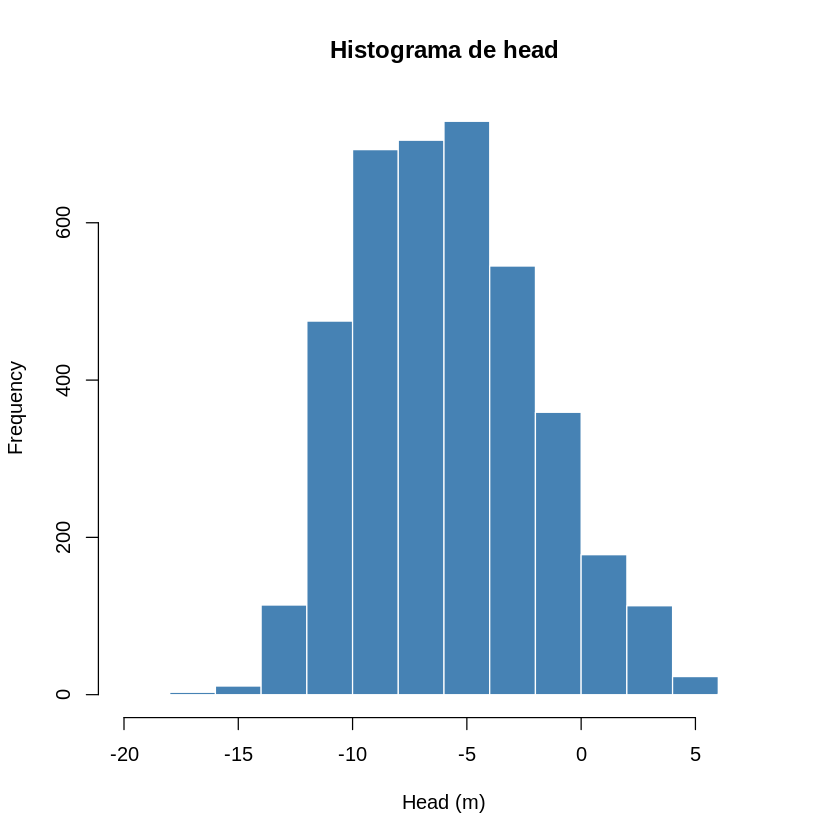

In [ ]:
# Histograma básico
hist(aquifer$head,
     main = "Histograma de head",
     xlab = "Head (m)",
     col  = "steelblue",
     border = "white")

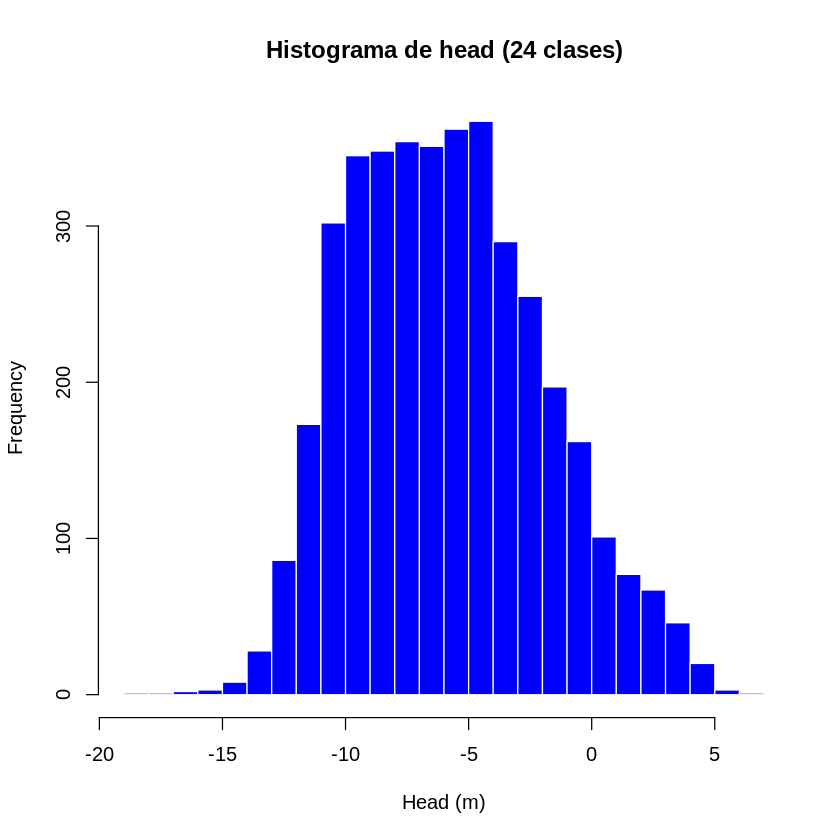

In [ ]:
# Histograma con 24 clases
hist(aquifer$head,
     breaks = 24,
     col    = "blue",
     border = "white",
     main   = "Histograma de head (24 clases)",
     xlab   = "Head (m)")

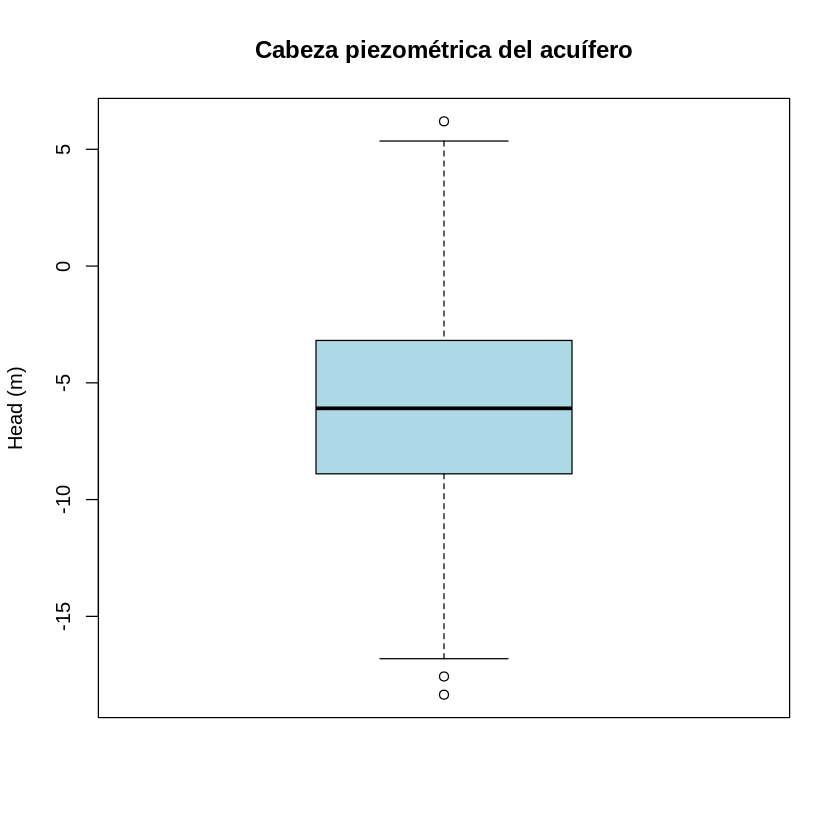

In [ ]:
# Diagrama de caja
boxplot(aquifer$head,
        main = "Cabeza piezométrica del acuífero",
        ylab = "Head (m)",
        col  = "lightblue")

---
## 🖼️ Actividad 4 — Cuatro gráficas en una sola hoja

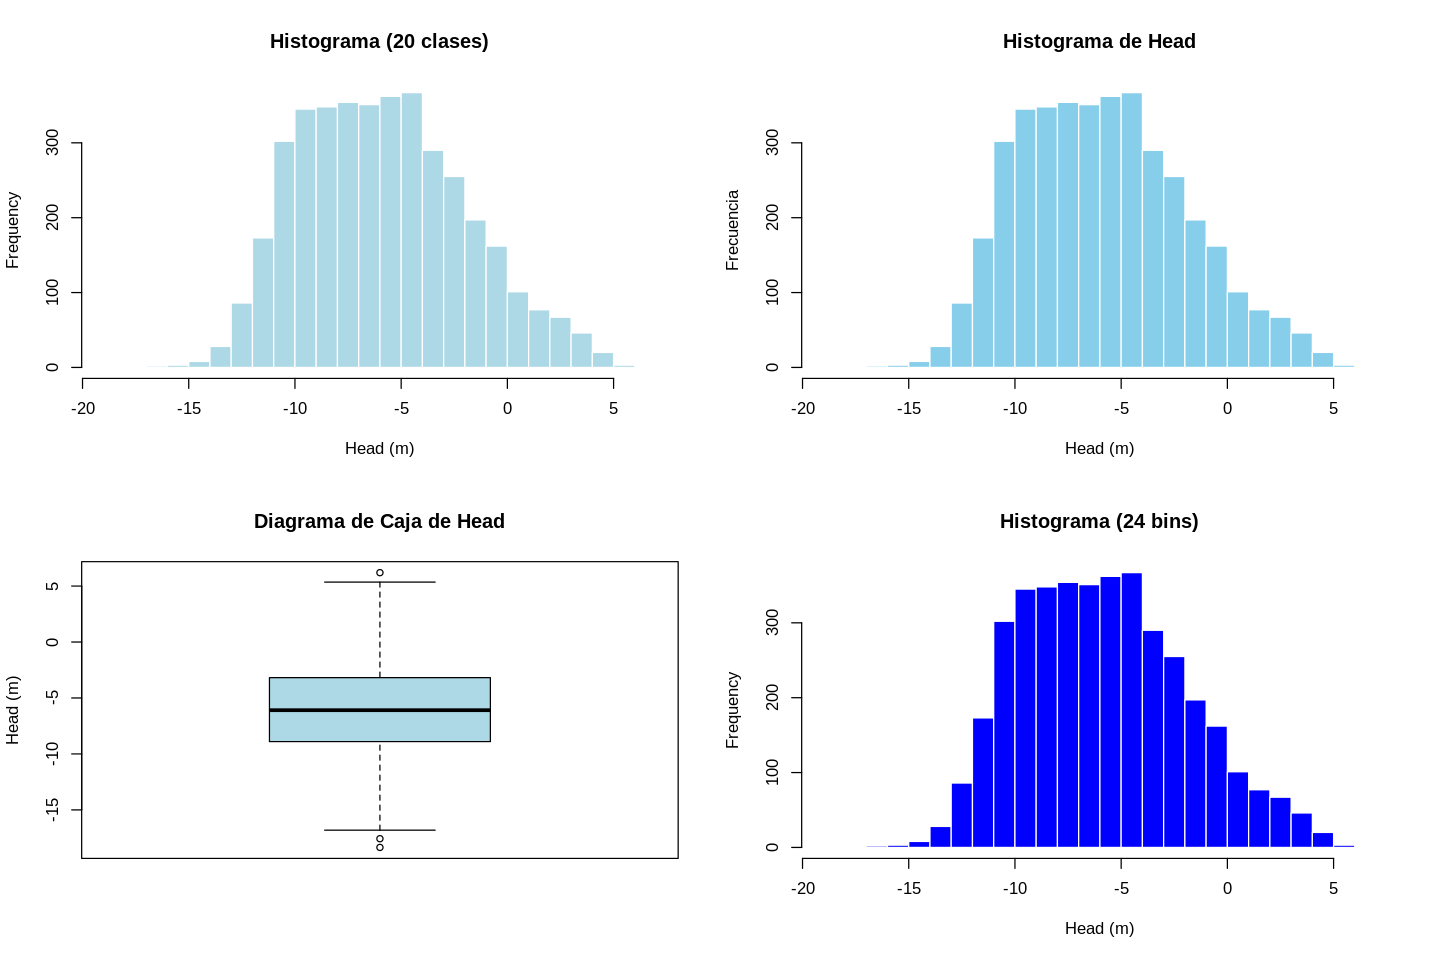

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)  # tamaño del lienzo en Colab

op <- par(mfrow = c(2, 2))

  hist(aquifer$head, nclass = 20,
       main = "Histograma (20 clases)",
       xlab = "Head (m)", col = "lightblue", border = "white")

  hist(aquifer$head, nclass = 20,
       main = "Histograma de Head",
       xlab = "Head (m)", ylab = "Frecuencia",
       col = "skyblue", border = "white")

  boxplot(aquifer$head,
          main = "Diagrama de Caja de Head",
          ylab = "Head (m)",
          col  = "lightblue")

  hist(aquifer$head, breaks = 24,
       col = "blue", border = "white",
       main = "Histograma (24 bins)",
       xlab = "Head (m)")

par(op)

---
## 🗂️ Actividad 5 — Grupos (estratificación) de las alturas de head

In [ ]:
# Estratificación con cut()
# Ajustamos los breaks para que cubran el rango real de los datos de 'head'
# y creamos 4 grupos equitativos.
min_head <- min(aquifer$head, na.rm = TRUE)
max_head <- max(aquifer$head, na.rm = TRUE)

# Crear 4 breaks espaciados uniformemente entre el mínimo y el máximo
breaks_for_groups <- seq(min_head, max_head, length.out = 5) # 5 puntos para 4 intervalos

head.groups_4 <- cut(
  aquifer$head,
  breaks = breaks_for_groups,
  labels = c("1", "2", "3", "4"),
  include.lowest = TRUE # Para incluir el valor mínimo en el primer intervalo
)

table(head.groups_4)  # conteo por grupo

head.groups_4
   1    2    3    4 
 112 1871 1659  308 

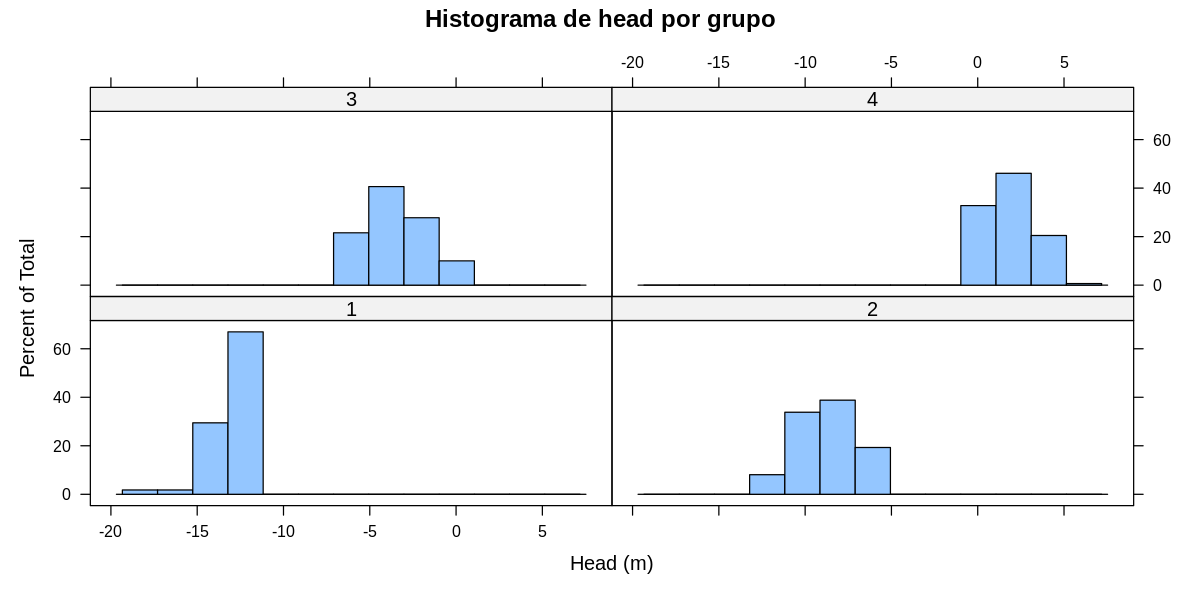

In [ ]:
# Histograma por grupo con lattice
options(repr.plot.width = 10, repr.plot.height = 5)
histogram(~ aquifer$head | head.groups_4,
          main = "Histograma de head por grupo",
          xlab = "Head (m)")

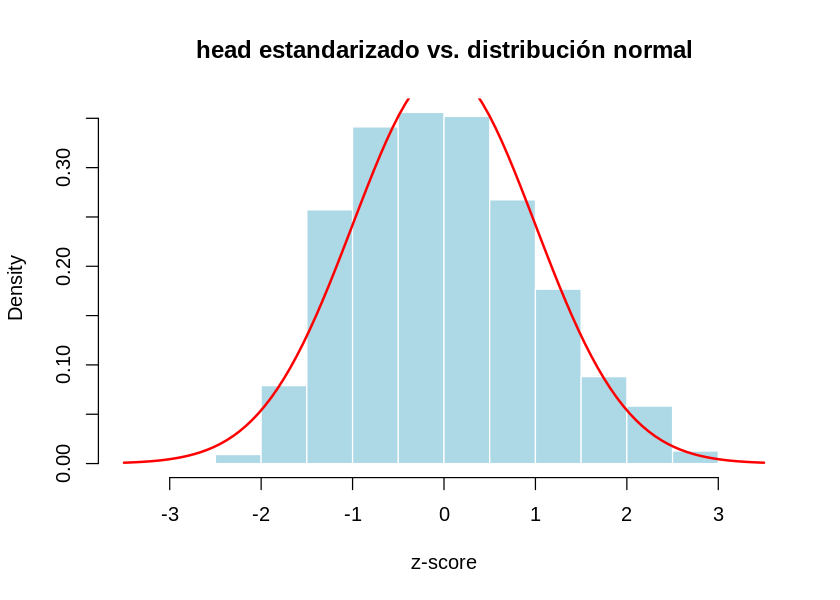

In [ ]:
# Histograma normalizado con curva normal superpuesta
options(repr.plot.width = 7, repr.plot.height = 5)
hist(
  (aquifer$head - mean(aquifer$head)) / sd(aquifer$head),
  freq  = FALSE,
  main  = "head estandarizado vs. distribución normal",
  xlab  = "z-score",
  col   = "lightblue",
  border = "white"
)
curve(dnorm(x), col = "red", lwd = 2, add = TRUE)

---
## 📐 Actividad 6 — QQ-Plot (verificación de normalidad)

> Si los puntos caen sobre la línea diagonal, los datos siguen una distribución normal.

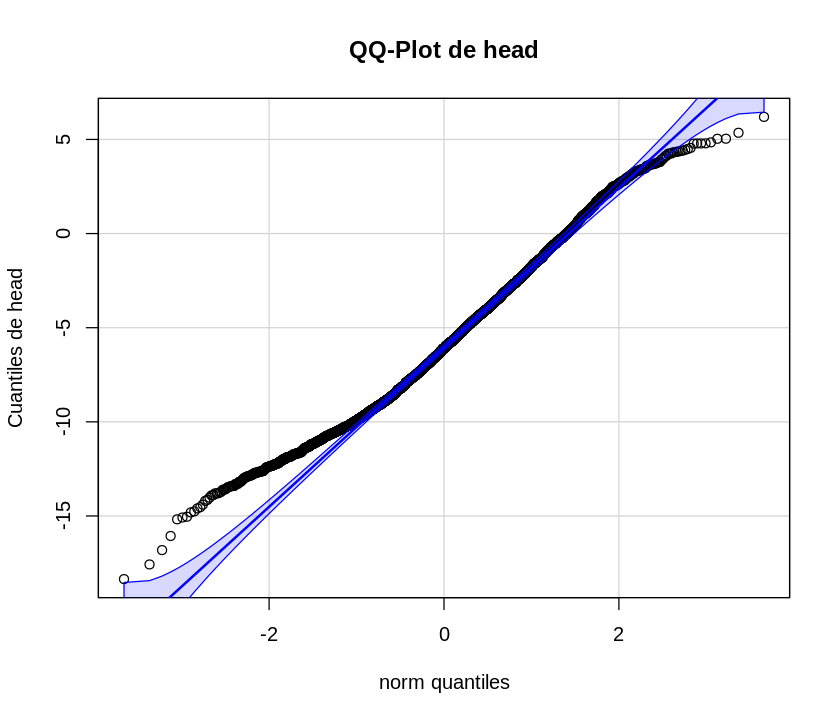

In [ ]:
options(repr.plot.width = 7, repr.plot.height = 6)
qqPlot(aquifer$head,
       main = "QQ-Plot de head",
       ylab = "Cuantiles de head",
       id   = FALSE)

---
## 🗺️ Actividad 7 — Gráfica de dispersión espacial

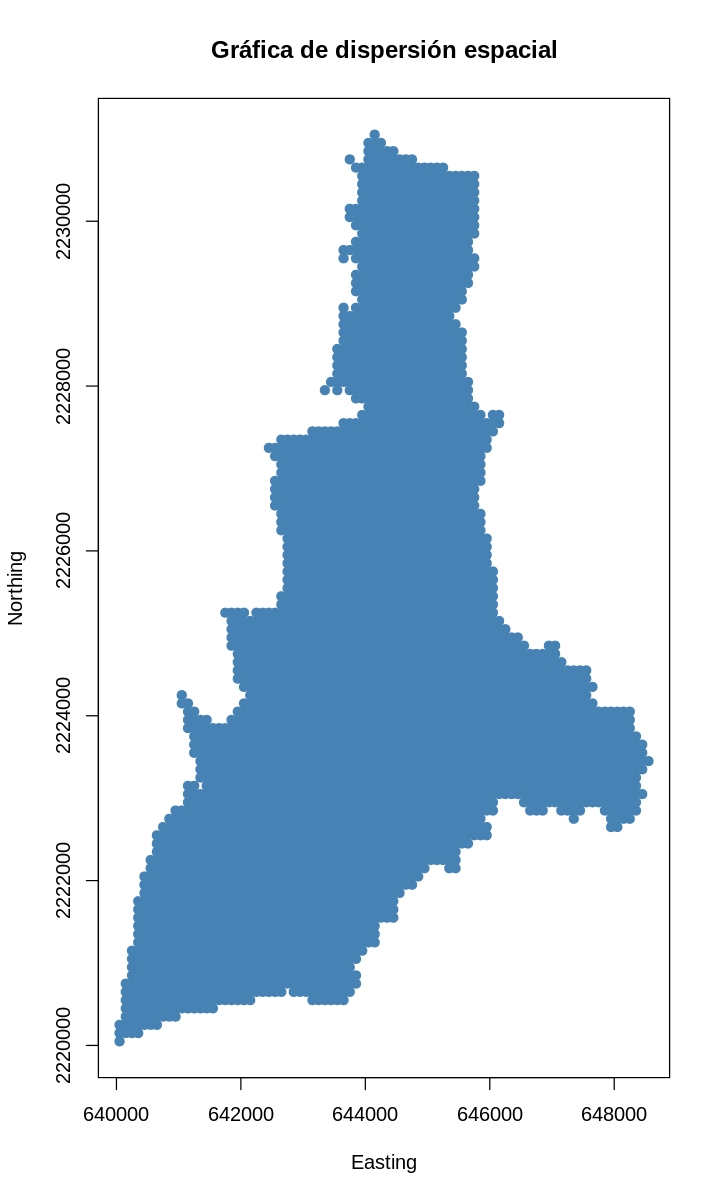

In [ ]:
# Diagrama de dispersión de las localizaciones
options(repr.plot.width = 6, repr.plot.height = 10)
plot(
  x    = aquifer$easting,
  y    = aquifer$northing,
  main = "Gráfica de dispersión espacial",
  xlab = "Easting",
  ylab = "Northing",
  pch  = 19,
  col  = "steelblue"
)

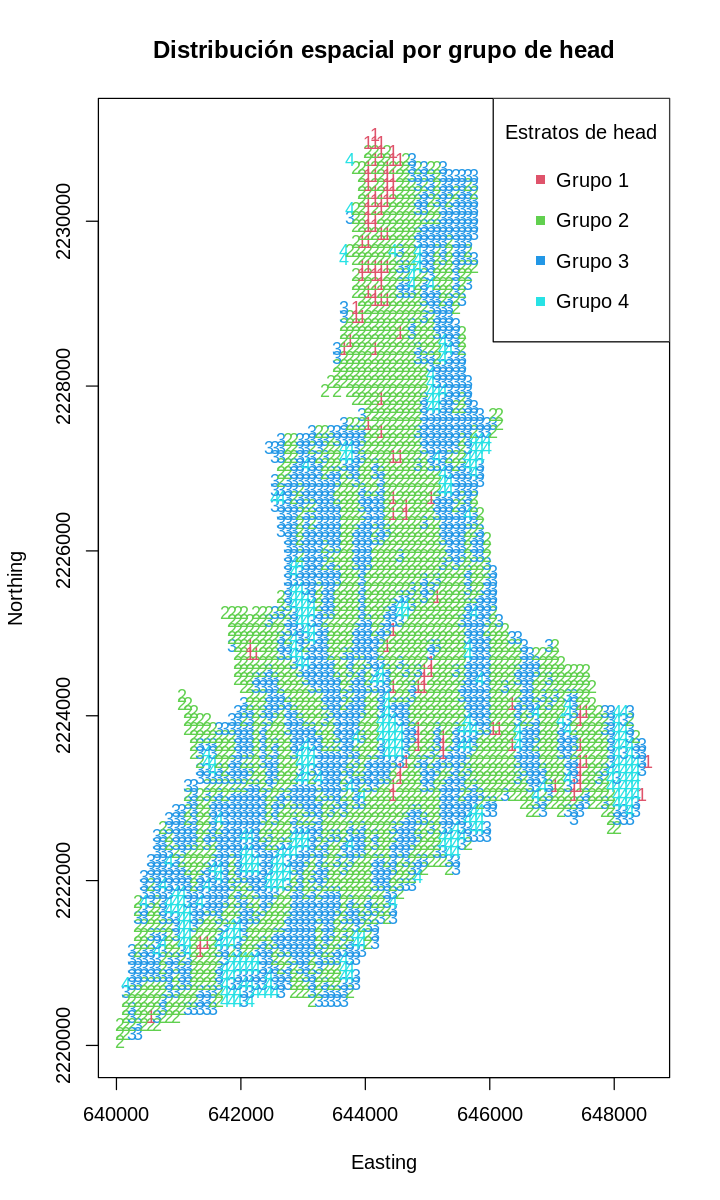

In [ ]:
# Dispersión con etiquetas de grupo
# type="n" dibuja solo el marco sin puntos
plot(
  x    = aquifer$easting,
  y    = aquifer$northing,
  type = "n",
  main = "Distribución espacial por grupo de head",
  xlab = "Easting",
  ylab = "Northing"
)
text(
  aquifer$easting, aquifer$northing,
  labels = head.groups_4,
  cex    = 0.9,
  col    = as.integer(head.groups_4) + 1  # color por grupo
)
legend("topright",
       legend = c("Grupo 1", "Grupo 2", "Grupo 3", "Grupo 4"),
       col    = 2:5,
       pch    = 15,
       title  = "Estratos de head")

---
## 🌐 Análisis Exploratorio Geoestadístico

Convertimos el dataframe en un objeto **geodata** con el paquete `geoR`.

In [ ]:
# Crear objeto geodata: columnas 1-2 son coordenadas, columna 3 es la variable
aquifer1 <- as.geodata(aquifer, coords.col = 1:2, data.col = 3)
str(aquifer1)

List of 2
 $ easting                 , northing                : num [1:3950, 1:2] 640050 640050 640150 640250 640350 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:2] "easting" "northing"
 $ data                    : num [1:3950] -9.96 -11.19 -11.8 -5.67 -5.76 ...
 - attr(*, "class")= chr "geodata"


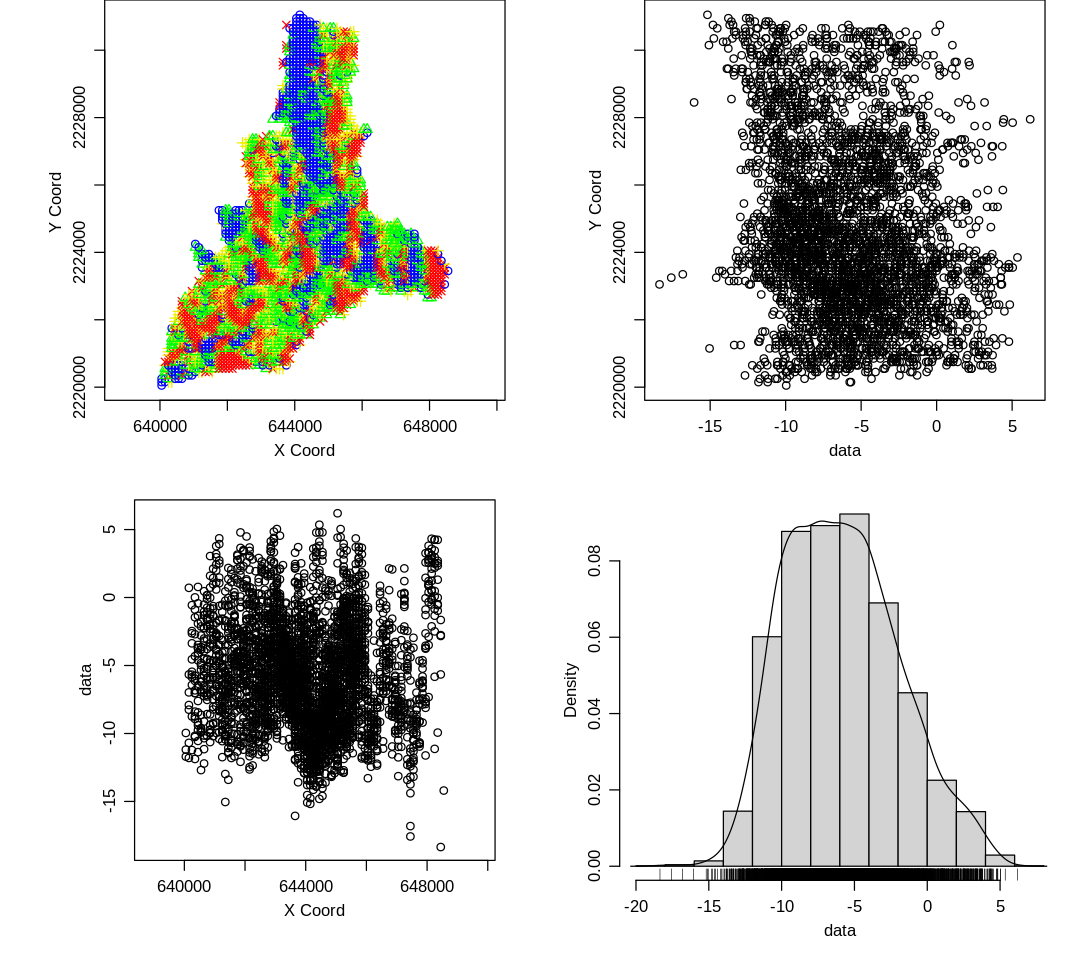

In [ ]:
# Gráfica exploratoria del objeto geodata
# Muestra dispersión, histograma marginal y tendencia en X e Y
options(repr.plot.width = 9, repr.plot.height = 8)
plot(aquifer1)

---
## 🔲 Actividad 8 — Superficie de interpolación

Usamos la función `interp()` del paquete `akima` para generar una malla de interpolación de `head`.

In [ ]:
# Interpolación en malla regular a partir de puntos dispersos
int.aq <- interp(
  x = aquifer$easting,
  y = aquifer$northing,
  z = aquifer$head
)

cat("Dimensiones de la malla:\n")
cat("  x:", length(int.aq$x), "puntos\n")
cat("  y:", length(int.aq$y), "puntos\n")
cat("  z: matriz", nrow(int.aq$z), "x", ncol(int.aq$z), "\n")

Dimensiones de la malla:
  x: 40 puntos
  y: 40 puntos
  z: matriz 40 x 40 


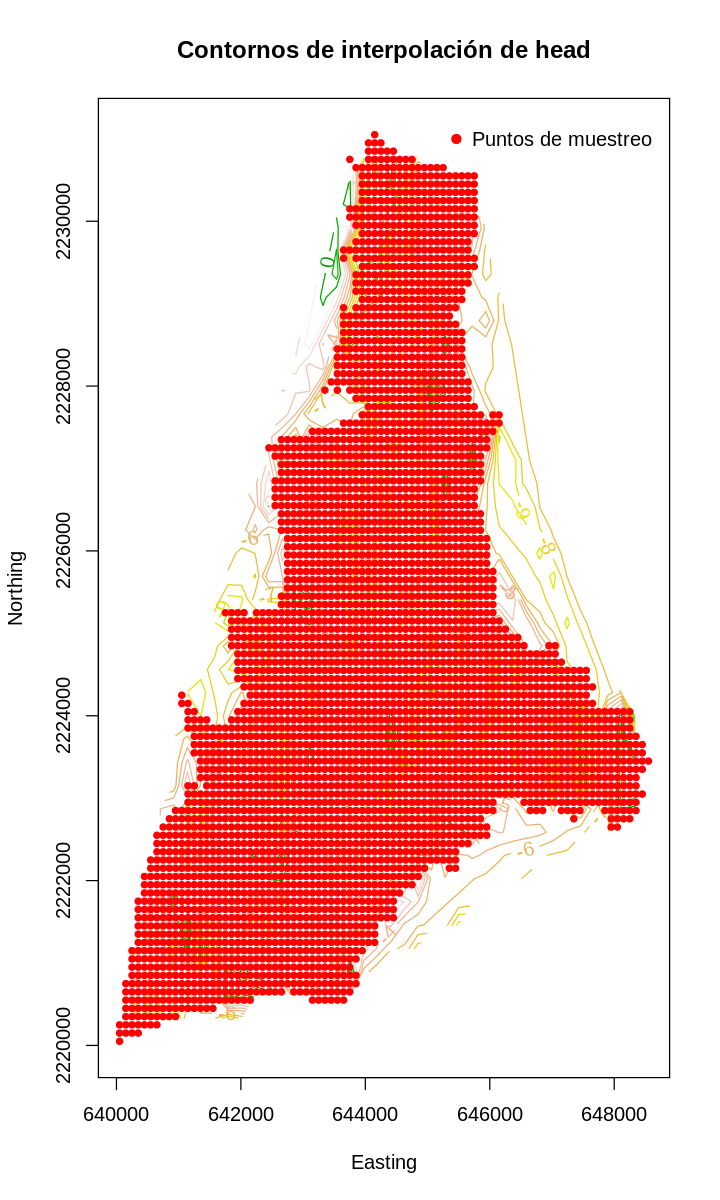

In [ ]:
# Líneas de contorno + puntos de muestreo
options(repr.plot.width = 6, repr.plot.height = 10)
contour(
  int.aq,
  labcex = 1,
  main   = "Contornos de interpolación de head",
  xlab   = "Easting",
  ylab   = "Northing",
  nlevels = 15, # Control the number of contour levels for better detail
  col = terrain.colors(15) # Apply a color gradient to the contour lines
)
points(
  aquifer$easting,
  aquifer$northing,
  pch = 19, cex = 0.7, col = "red"
)
legend("topright", legend = "Puntos de muestreo",
       pch = 19, col = "red", bty = "n")

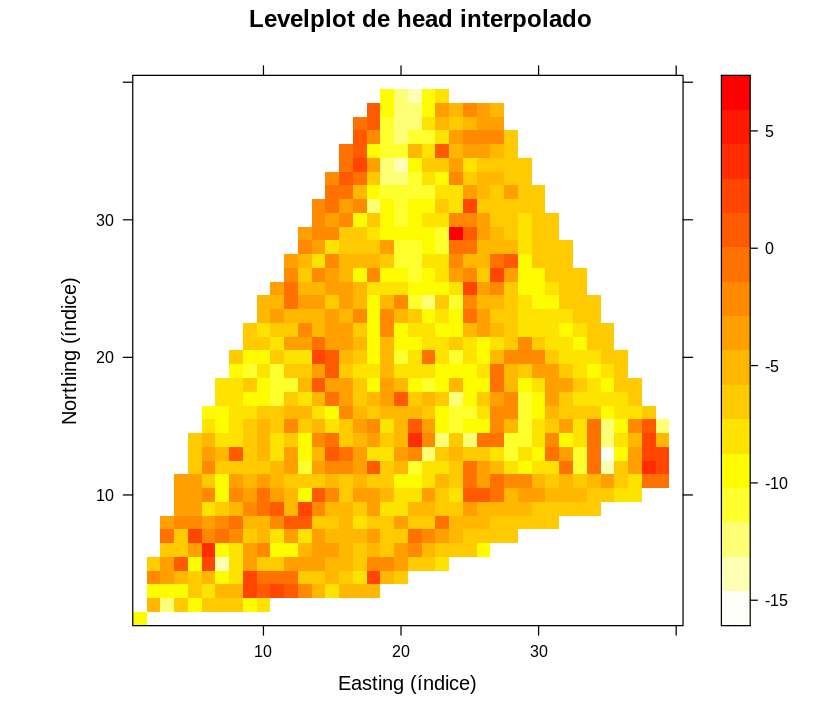

In [ ]:
# Mapa de calor con levelplot (lattice)
options(repr.plot.width = 7, repr.plot.height = 6)
levelplot(int.aq$z,
          main   = "Levelplot de head interpolado",
          xlab   = "Easting (índice)",
          ylab   = "Northing (índice)",
          col.regions = heat.colors(100, rev = TRUE))

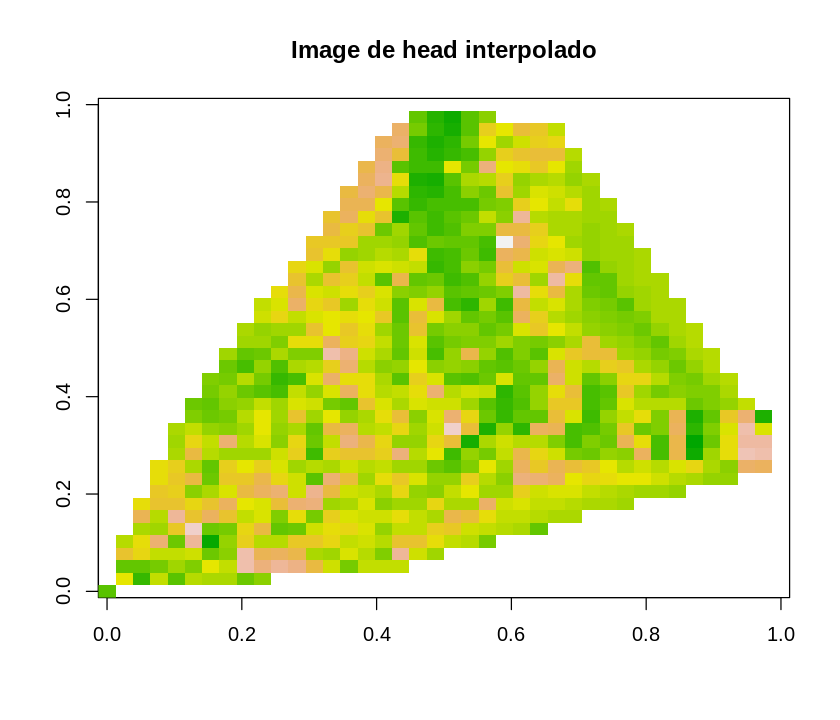

In [ ]:
# Representación con image() (graphics base)
options(repr.plot.width = 7, repr.plot.height = 6)
image(
  int.aq$z,
  main = "Image de head interpolado",
  col  = terrain.colors(50)
)

---
## 🏔️ Actividad 9 — Visualización 3D de la superficie interpolada

> Parámetros clave de `persp()`:
> - `phi`: rotación en el eje Z (elevación)
> - `theta`: rotación en el eje Y (azimut)
> - `ticktype="detailed"`: muestra valores en los ejes

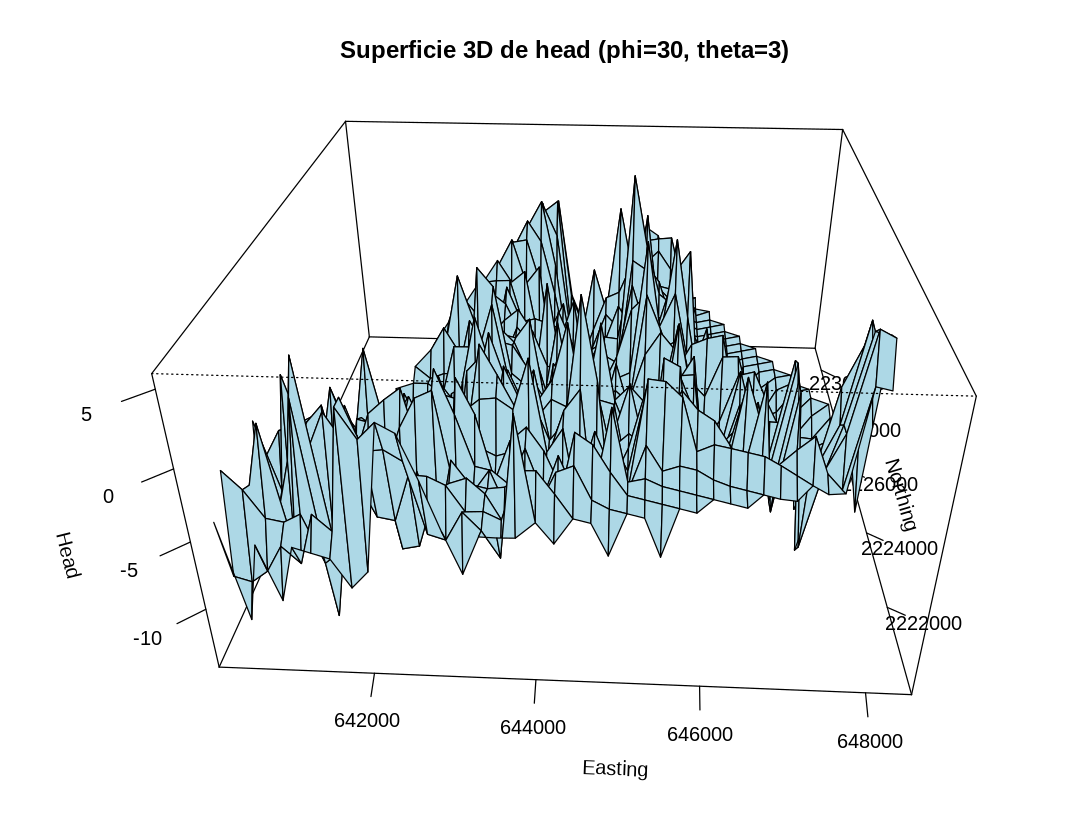

In [ ]:
# Vista 1: phi=30, theta=3
options(repr.plot.width = 9, repr.plot.height = 7)
persp(
  int.aq$x, int.aq$y, int.aq$z,
  xlab     = "Easting",
  ylab     = "Northing",
  zlab     = "Head",
  phi      = 30,
  theta    = 3,
  col      = "lightblue",
  expand   = 0.5,
  ticktype = "detailed",
  main     = "Superficie 3D de head (phi=30, theta=3)"
)

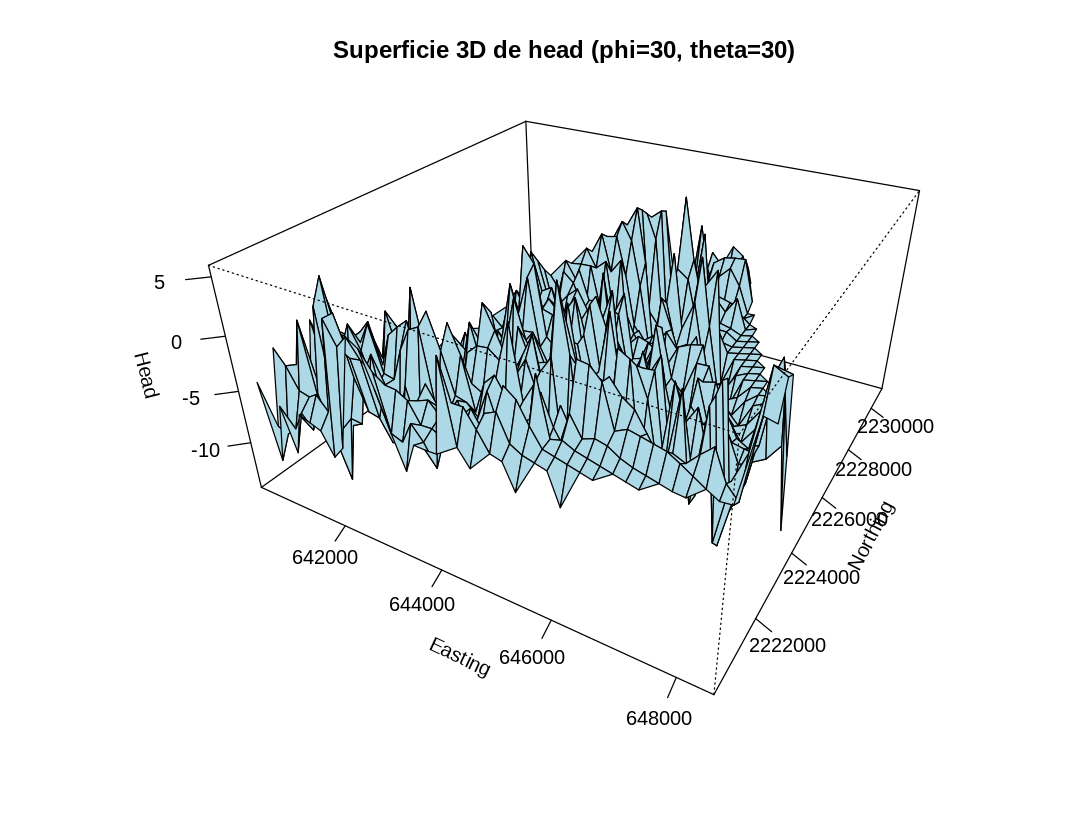

In [ ]:
# Vista 2: phi=30, theta=30
persp(
  int.aq$x, int.aq$y, int.aq$z,
  xlab     = "Easting",
  ylab     = "Northing",
  zlab     = "Head",
  phi      = 30,
  theta    = 30,
  col      = "lightblue",
  expand   = 0.5,
  ticktype = "detailed",
  main     = "Superficie 3D de head (phi=30, theta=30)"
)

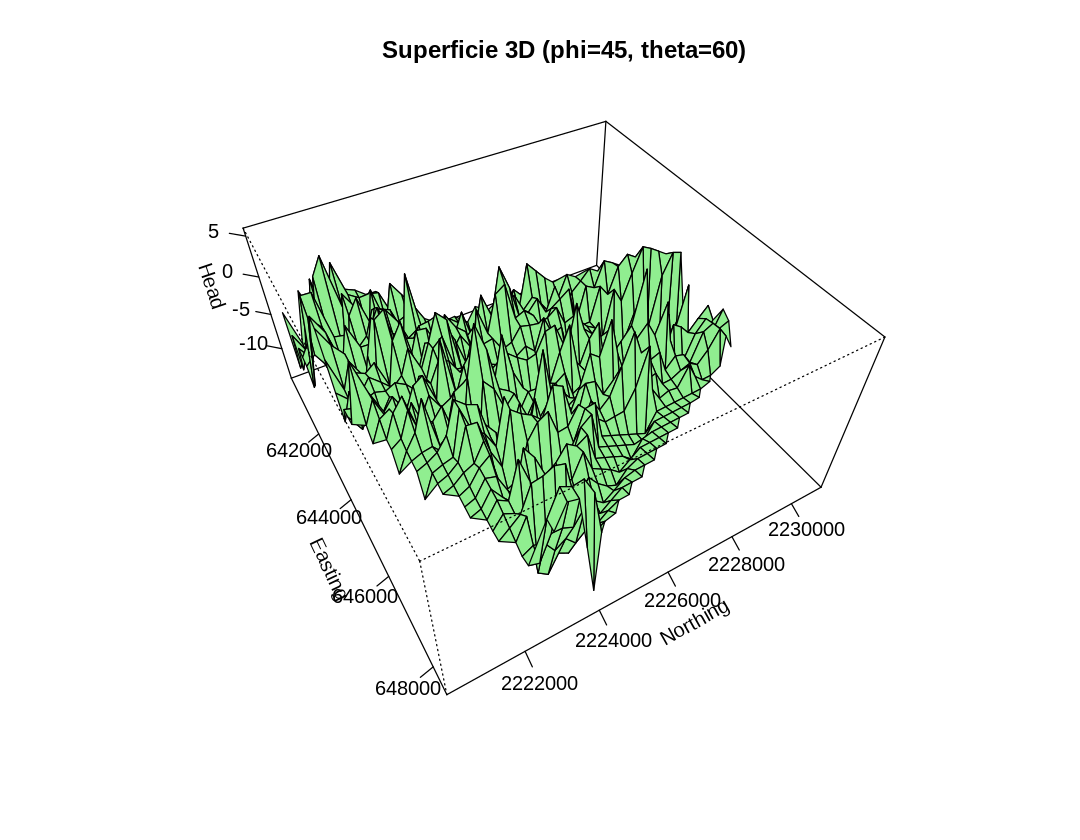

In [ ]:
# Exploración de ángulos: modificar phi y theta para encontrar la mejor visualización
phi_val   <- 45   # <-- cambia este valor
theta_val <- 60   # <-- cambia este valor

persp(
  int.aq$x, int.aq$y, int.aq$z,
  xlab     = "Easting",
  ylab     = "Northing",
  zlab     = "Head",
  phi      = phi_val,
  theta    = theta_val,
  col      = "lightgreen",
  expand   = 0.5,
  ticktype = "detailed",
  main     = paste0("Superficie 3D (phi=", phi_val, ", theta=", theta_val, ")")
)

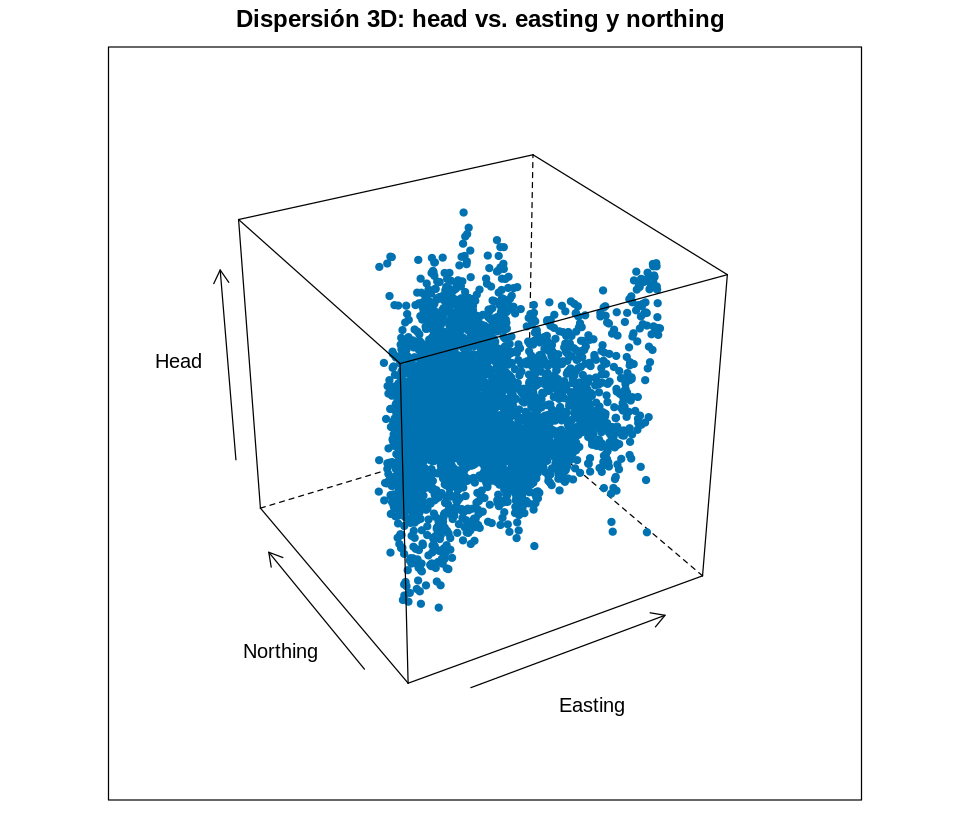

In [ ]:
# Diagrama de dispersión tridimensional con cloud (lattice)
options(repr.plot.width = 8, repr.plot.height = 7)
cloud(
  head ~ easting * northing,
  data   = aquifer,
  main   = "Dispersión 3D: head vs. easting y northing",
  xlab   = "Easting",
  ylab   = "Northing",
  zlab   = "Head",
  pch    = 19,
  cex    = 0.7,
  screen = list(z = 30, x = -60)  # ajusta el ángulo de visión
)

---
## 🔍 Preguntas de análisis

Responde estas preguntas basándote en las gráficas obtenidas:

1. **¿Las superficies presentan tendencia espacial?**  
   _Observa si existe un gradiente sistemático en la dirección este o norte._

2. **¿Existen observaciones que se puedan considerar atípicas? ¿Por qué?**  
   _Revisa el boxplot y el QQ-plot._

3. **¿Cuál combinación de `phi` y `theta` en `persp()` ofrece la mejor visualización?**  
   _Usa la celda de "Exploración de ángulos" para experimentar._

4. **¿Qué revela el gráfico `cloud()` sobre la distribución espacial de head?**

---
_Notebook generado a partir del script R del Ejercicio 1 — Análisis Exploratorio Geoestadístico_